# RL-NDVI (copied) — NDVI MSE + Clase BCE
Este notebook es una copia simplificada del original con el `MultiSeriesSamplerEnv` modificado: NDVI como MSE continuo y clase como cross-entropy (BCE).

In [1]:
# Imports y dependencias (mismo que original)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

# stable-baselines3 (si quieres entrenar desde aqui)
try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print('Instala stable-baselines3 para entrenar aquí')

In [2]:
# Cargar datos (igual que en el notebook original)
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder + filename)
ndviDataStart = 7
fechas = pd.to_datetime(df.columns[ndviDataStart:])
df['fechaDef'] = pd.to_datetime({'year': df['anio'].astype(int), 'month': df['mes'].astype(int), 'day': 1})
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
# Construir train_list/test_list como en el original (usa testPixel aleatorio)
nSeries = 500
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)
fTrain = 0.8
nTrain = int(nSeries * fTrain)
trainSeries = np.random.choice(testPixel, size=nTrain, replace=False)
testSeries = [int(i) for i in testPixel if i not in trainSeries]
train_list = []
test_list = []
for i in trainSeries:
    ndvi_list = df.iloc[i, ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i]
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    train_list.append([ndvi_list, input2])
for i in testSeries:
    ndvi_list = df.iloc[i, ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i]
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    test_list.append([ndvi_list, input2])
print('Train/test lists prepared:', len(train_list), len(test_list))

Train/test lists prepared: 400 100


In [3]:
# Entorno modificado: NDVI=MSE, Clase=BCE (sin reward por secuencia)
class MultiSeriesSamplerEnv(gym.Env):
    def __init__(self, series_pairs, window=23, ndvi_weight=1.0, class_weight=1.0):
        super().__init__()
        import numpy as _np
        from gymnasium import spaces as _spaces
        self.series_pairs = series_pairs
        self.n_series = len(series_pairs)
        self.window = window
        # length debe considerar ambas series (NDVI y class) por si difieren
        self.length = min(min(len(s[0]), len(s[1])) for s in series_pairs)
        self.observation_space = _spaces.Box(low=-1.5, high=1.5, shape=(window, 2), dtype=_np.float32)
        self.action_space = _spaces.Box(low=-5.0, high=5.0, shape=(2,), dtype=_np.float32)
        # weights
        self.ndvi_weight = float(ndvi_weight)
        self.class_weight = float(class_weight)
        self._eps = 1e-8

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        import numpy as _np
        # elegir una serie al azar para el episodio
        self.current_series = _np.random.randint(0, self.n_series)
        self.current_step = self.window
        ndvi = _np.array(self.series_pairs[self.current_series][0], dtype=_np.float32)
        cat  = _np.array(self.series_pairs[self.current_series][1], dtype=_np.float32)
        # Asegurar que ambas tengan la misma longitud (truncar al mínimo)
        min_len = min(len(ndvi), len(cat))
        ndvi = ndvi[:min_len]
        cat = cat[:min_len]
        # actualizar self.length si es necesario (seguro para episodios)
        self.length = min(self.length, min_len)
        self.data = _np.stack([ndvi, cat], axis=1)  # shape (min_len, 2)
        obs = self.data[self.current_step - self.window : self.current_step]
        return obs, {}

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-x))

    def step(self, action):
        import numpy as _np
        # target at current step (next to predict)
        target = self.data[self.current_step]
        # separate NDVI and class targets/actions
        ndvi_t = float(target[0])
        class_t = float(target[1])
        a_ndvi = float(action[0])
        a_class = float(action[1])  # treated as logit / real-valued score
        # NDVI loss: MSE
        mse_ndvi = (a_ndvi - ndvi_t) ** 2
        # Class loss: binary cross-entropy using sigmoid(a_class) as predicted prob
        p = self._sigmoid(a_class)
        # numerically-stable BCE approximation
        bce = - (class_t * np.log(p + self._eps) + (1.0 - class_t) * np.log(1.0 - p + self._eps))
        # per-step combined loss (weighted)
        per_step_loss = (self.ndvi_weight * mse_ndvi) + (self.class_weight * bce)
        per_step_reward = -per_step_loss
        # advance
        self.current_step += 1
        done = self.current_step >= self.length
        # next observation
        if not done:
            next_obs = self.data[self.current_step - self.window : self.current_step]
        else:
            next_obs = _np.zeros((self.window, 2), dtype=_np.float32)
        info = {
            'mse_ndvi': mse_ndvi,
            'bce_class': bce,
            'current_series': int(self.current_series)
        }
        return next_obs, float(per_step_reward), bool(done), False, info

In [4]:
# Crear env con el wrapper modificado y hacer un smoke-test
env = MultiSeriesSamplerEnv(train_list, window=23, ndvi_weight=1.0, class_weight=1.0)
obs, _ = env.reset()
print('Obs shape:', obs.shape)
# dar algunos pasos aleatorios y ver info
a = env.action_space.sample()
next_obs, r, done, _, info = env.step(a)
print('Step reward example:', r)
print('Info example:', {k: info[k] for k in ['mse_ndvi','bce_class','current_series']})
# avanzar hasta el final del episodio para ver reward por secuencia agregado
total_r = 0.0
cnt = 0
while True:
    a = env.action_space.sample()
    next_obs, r, done, _, info = env.step(a)
    total_r += r
    cnt += 1
    if done:
        print('Episode finished in steps:', cnt, 'total reward:', total_r)
        break

Obs shape: (23, 2)
Step reward example: -7.781090887983657
Info example: {'mse_ndvi': 7.759749537793973, 'bce_class': np.float64(0.021341350189683996), 'current_series': 5}
Episode finished in steps: 406 total reward: -3779.334857602516


In [5]:
# Entrenamiento (igual que antes, usar DummyVecEnv y PPO). Ajusta total_timesteps si quieres correr en serio.
from stable_baselines3.common.vec_env import DummyVecEnv
vec_env = DummyVecEnv([lambda: env])
model = PPO("MlpPolicy", vec_env, verbose=1, tensorboard_log='./tb_seqreward')
# Nota: esto entrenará con las recompensas modificadas (NDVI MSE + Clase BCE)
# model.learn(total_timesteps=300_000)
print('Listo para entrenar. Descomenta model.learn(...) para ejecutar')

Using cpu device
Listo para entrenar. Descomenta model.learn(...) para ejecutar


In [6]:
# Entrenamiento con Monitor + VecNormalize y guardado de stats
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import os

log_dir = './logs_seqreward'
os.makedirs(log_dir, exist_ok=True)

def make_env():
    return Monitor(MultiSeriesSamplerEnv(train_list, window=23, ndvi_weight=1.0, class_weight=1.0))

vec_env = DummyVecEnv([make_env])
vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False)

# Ajustes recomendados: aumentar n_steps a la longitud típica del episodio (p.ej. 256-2048)
model = PPO('MlpPolicy', vec_env, verbose=1, tensorboard_log='./tb_seqreward', n_steps=512)

# Para pruebas rápidas: usar pocos timesteps. Para entrenamiento serio usa 300_000 o más.
quick_timesteps = 300_000
model.learn(total_timesteps=quick_timesteps)

# Guardar modelo y estadísticas de normalización
model.save(os.path.join(log_dir, 'ppo_ndvi_seqreward_test'))
vec_env.save(os.path.join(log_dir, 'vecnormalize_stats.pkl'))
print('Modelo y stats guardados en', log_dir)

Using cpu device
Logging to ./tb_seqreward/PPO_3
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 407      |
|    ep_rew_mean     | -793     |
| time/              |          |
|    fps             | 3708     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 407         |
|    ep_rew_mean          | -771        |
| time/                   |             |
|    fps                  | 2824        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.005634064 |
|    clip_fraction        | 0.0289      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.83       |
|    explained_variance

Test idx 9: NDVI RMSE=0.1123, Class acc=0.7150


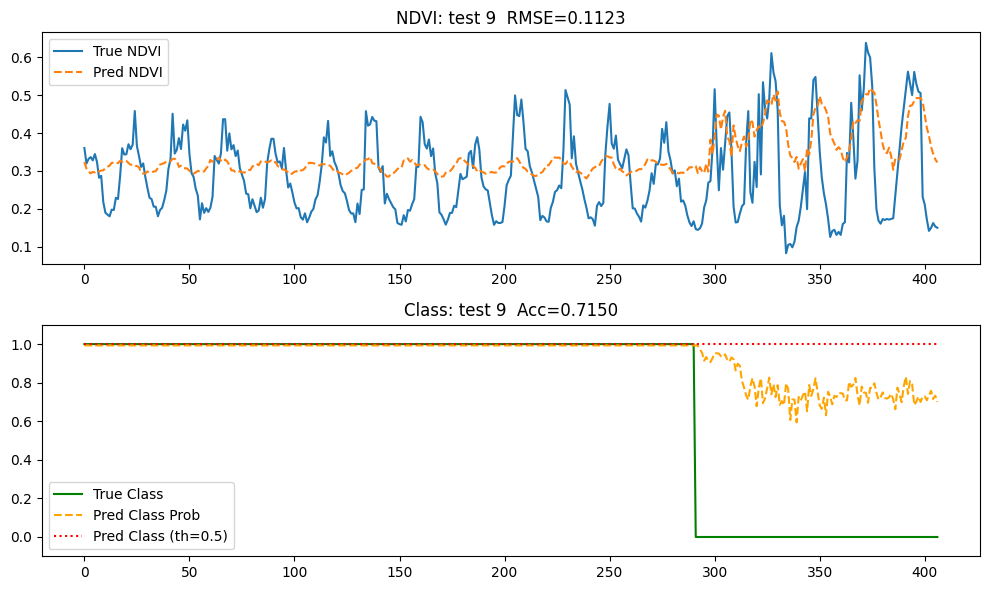

Test idx 44: NDVI RMSE=0.0938, Class acc=0.8133


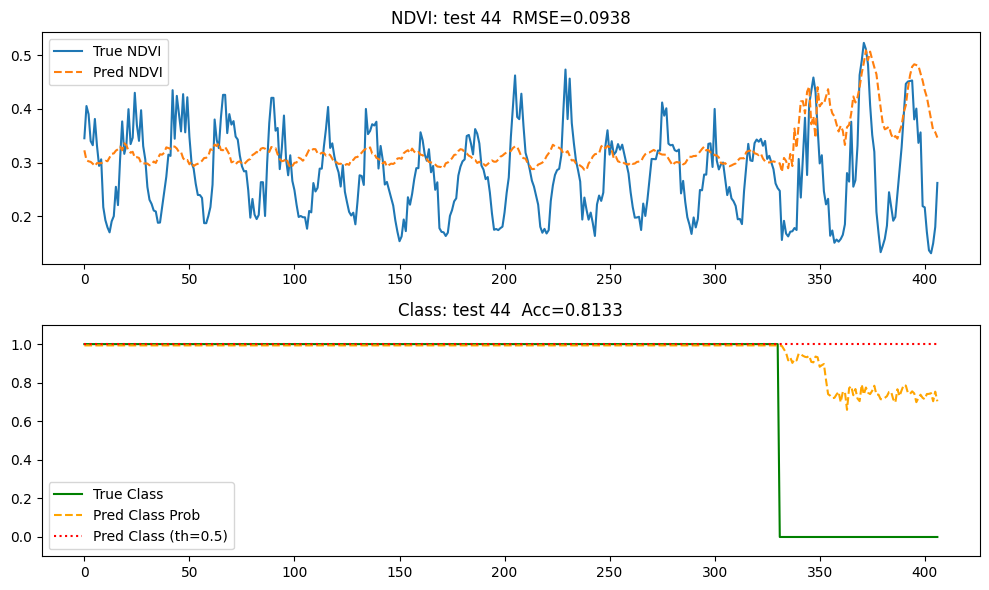

Test idx 19: NDVI RMSE=0.0939, Class acc=0.8698


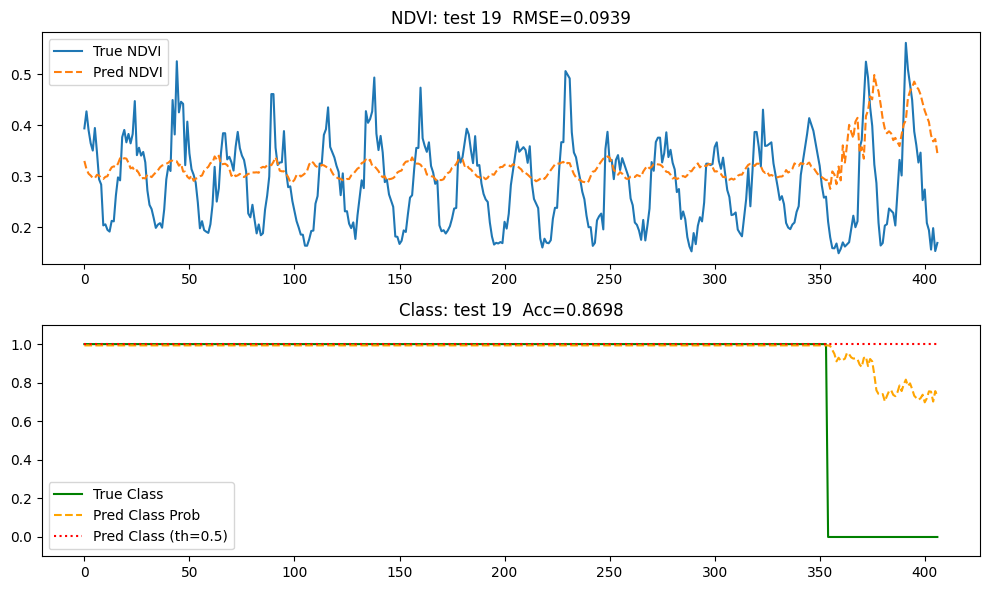

Test idx 26: NDVI RMSE=0.0902, Class acc=0.8501


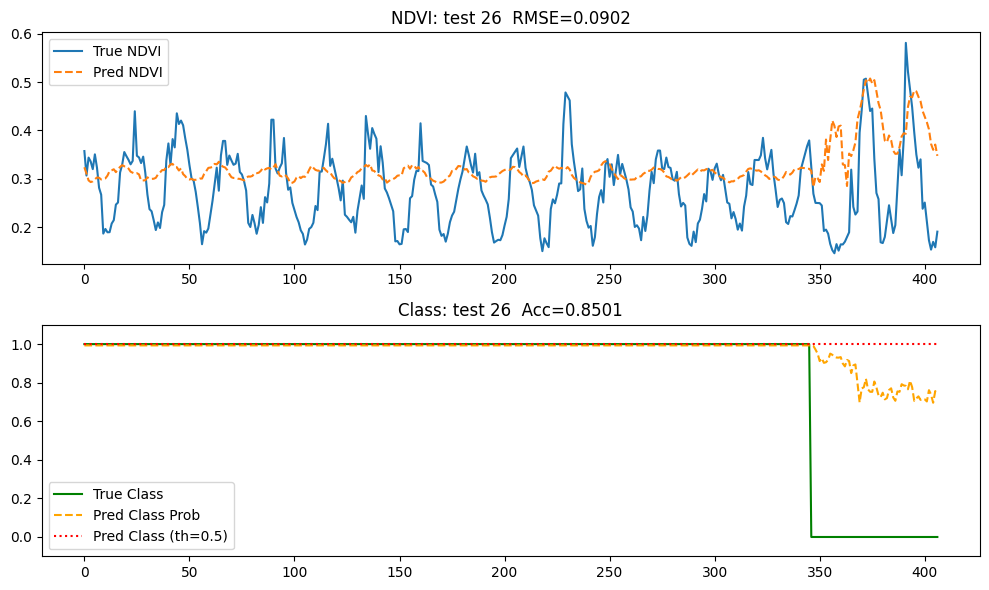

Test idx 21: NDVI RMSE=0.1151, Class acc=0.6388


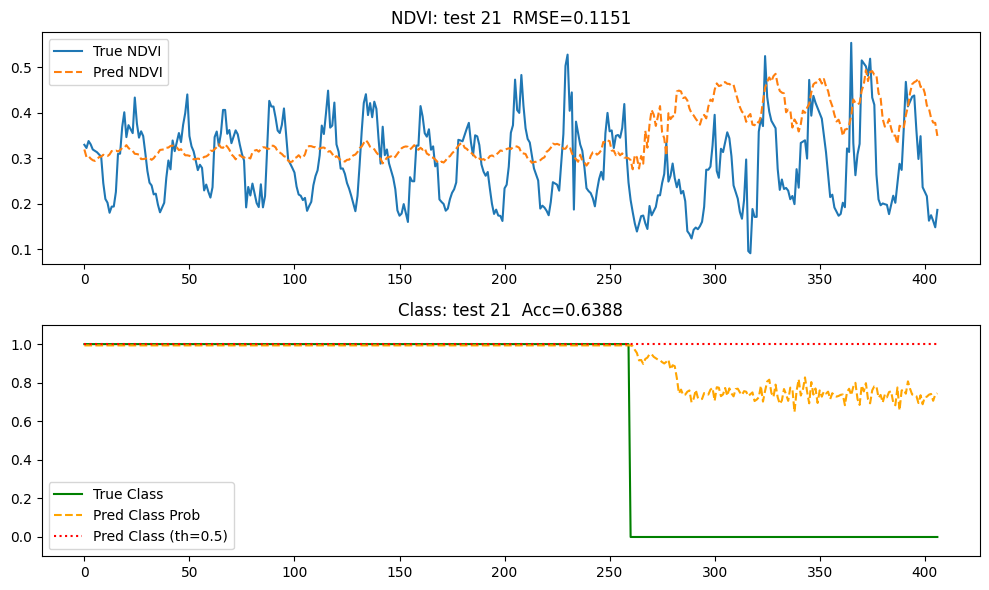

In [7]:
# Evaluación y plots de resultados (RMSE para NDVI, accuracy para clase)
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

ntoShow = min(5, len(test_list))
toShowList = np.random.choice(len(test_list), size=ntoShow, replace=False)

for idx in toShowList:
    pair = test_list[idx]  # [ndvi_array, class_array]
    test_env = MultiSeriesSamplerEnv([pair], window=23)  # env with single series
    obs, _ = test_env.reset()
    preds = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action = np.array(action).ravel()
        obs, reward, done, _, info = test_env.step(action)
        preds.append(action.copy())
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    # Metrics
    ndvi_rmse = np.sqrt(np.mean((preds[:,0] - true_vals[:,0])**2))
    class_probs = sigmoid(preds[:,1])
    class_pred = (class_probs >= 0.5).astype(float)
    class_true = true_vals[:,1]
    class_acc = (class_pred == class_true).mean() if len(class_true)>0 else np.nan
    print(f'Test idx {idx}: NDVI RMSE={ndvi_rmse:.4f}, Class acc={class_acc:.4f}')
    # Plots
    time_axis = np.arange(len(preds))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6))
    ax1.plot(time_axis, true_vals[:,0], label='True NDVI')
    ax1.plot(time_axis, preds[:,0], '--', label='Pred NDVI')
    ax1.set_title(f'NDVI: test {idx}  RMSE={ndvi_rmse:.4f}')
    ax1.legend()
    ax2.plot(time_axis, class_true, label='True Class', color='green')
    ax2.plot(time_axis, class_probs, '--', label='Pred Class Prob', color='orange')
    ax2.plot(time_axis, class_pred, ':', label='Pred Class (th=0.5)', color='red')
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_title(f'Class: test {idx}  Acc={class_acc:.4f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()